# Week 3 — Marketing Mix Modeling: from spend to a defensible reallocation
## Case: GLUCOREN, three years after launch — five channels, one competitor, one formulary win

**Applied Data Science and AI in Pharma Commercial · Columbia DSI · Fall 2026 · Monday, September 28**

Weeks 1–2 gave you the market (who chooses, who pays) and the data (projected TRx). Tonight the Brand Lead asks the question every brand team hears at every quarterly business review:

> *"We spent $78M promoting GLUCOREN since launch. Which $10M would you cut — and how sure are you?"*

The structure of the night is the structure of a real MMM engagement:

1. **EDA** — what the brand's spend and TRx look like, and why same-week correlation lies.
2. **Adstock and saturation** — the two transforms that let a regression see marketing.
3. **Baseline controls** — launch ramp, seasonality, the competitor, the formulary win. In pharma the controls matter as much as the channels.
4. **Fit an OLS MMM** — grid-search the non-linear parameters, let OLS solve the linear ones.
5. **Diagnose** — residuals, VIF, coefficient signs, a hold-out.
6. **Decompose** — base vs. incremental; the chart leadership wants.
7. **ROI** — average vs. marginal, and why they rank channels differently.
8. **Grade against the truth** — the data is synthetic, so we can (instructor file).
9. **Uncertainty** — block bootstrap and hyperparameter sensitivity: ranges, not points.
10. **Calibrate with an experiment** — a DTC-TV geo holdout.
11. **Reallocate** — equalize marginal ROI under real constraints; two scenarios.

The data is **synthetic** and generated from a known response model, which is the only reason section 8 is possible. No real brand, spend or prescriptions are represented.

| file | grain | what it represents |
|---|---|---|
| `glucoren_weekly_mmm.csv` | one row per week (156) | projected national TRx; spend by channel; HCP call count; competitor flag; PBM preferred-status share |
| `glucoren_geo_lift_dtc_tv.csv` | one row per DMA × week (40 × 16) | a DTC-TV holdout experiment: 8 pre-weeks, 8 test weeks, 10 dark DMAs |
| `_INSTRUCTOR_mmm_truth.json`, `_INSTRUCTOR_true_contributions.csv`, `_INSTRUCTOR_geo_lift_truth.json` | — | the generating parameters (in `instructor material/`; the grading cells print a notice and skip if absent) |


## 1. Setup

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
NAVY, CORAL, ICE, TEAL, GOLD, GREY = "#1E2761", "#FF6B6B", "#CADCFC", "#2A9D8F", "#E8B04B", "#8A8A8A"
PALETTE = {"base": ICE, "hcp_detailing": NAVY, "conferences": GOLD, "digital": TEAL, "email": "#7B61FF", "dtc_tv": CORAL}
np.random.seed(7)

# The package keeps data in ./data and instructor files in ./instructor material; a flat folder also works.
DATA = next((p for p in [Path("data"), Path(".")] if (p / "glucoren_weekly_mmm.csv").exists()), Path("."))
INSTR = next((p for p in [Path("instructor material"), Path("data"), Path(".")] if (p / "_INSTRUCTOR_mmm_truth.json").exists()), Path("instructor material"))
df = pd.read_csv(DATA / "glucoren_weekly_mmm.csv", parse_dates=["week"])
CHANNELS = ["hcp_detailing", "conferences", "digital", "email", "dtc_tv"]
SPEND = [f"{c}_spend" for c in CHANNELS]
REV_PER_TRX = 250          # placeholder contribution per TRx — from Week 1's P&L (~$252). Finance owns this number.
T = len(df); t = np.arange(T)
print(df.shape, df.week.min().date(), "→", df.week.max().date())
df.head()

(156, 10) 2023-07-03 → 2026-06-22


,week,trx,hcp_detailing_spend,conferences_spend,digital_spend,email_spend,dtc_tv_spend,hcp_calls,competitor_active,pbm_preferred_share
0,2023-07-03,1581,74074,0,47857,14405,0,180,0,0.38
1,2023-07-10,2519,129041,0,56909,14929,0,312,0,0.38
2,2023-07-17,3894,167790,250000,57558,14774,0,415,0,0.38
3,2023-07-24,3233,160280,0,58951,0,0,394,0,0.38
4,2023-07-31,3191,162482,0,59616,14253,0,423,0,0.38


In [2]:
summary = df[["trx"] + SPEND + ["hcp_calls"]].describe().T[["mean", "std", "min", "max"]].round(0)
summary["total_$M" if False else "total"] = df[["trx"] + SPEND + ["hcp_calls"]].sum().round(0)
print(summary)
print(f"\nTotal promotional spend over the launch period: ${df[SPEND].sum().sum()/1e6:,.1f}M  (≈ ${df[SPEND].sum().sum()/3e6:,.1f}M / year)")
print("Share of spend by channel:", (df[SPEND].sum() / df[SPEND].sum().sum()).round(3).to_dict())

                         mean       std      min       max     total
trx                   10441.0    3097.0   1581.0   15183.0   1628756
hcp_detailing_spend  167314.0   29027.0  60089.0  227478.0  26100936
conferences_spend     58119.0  159630.0      0.0  749773.0   9066487
digital_spend         90227.0   51104.0   8000.0  231131.0  14075449
email_spend            6687.0    4916.0      0.0   15911.0   1043229
dtc_tv_spend         176644.0  216502.0      0.0  540881.0  27556524
hcp_calls               403.0      71.0    145.0     539.0     62857

Total promotional spend over the launch period: $77.8M  (≈ $25.9M / year)
Share of spend by channel: {'hcp_detailing_spend': 0.335, 'conferences_spend': 0.116, 'digital_spend': 0.181, 'email_spend': 0.013, 'dtc_tv_spend': 0.354}


## 2. EDA — three plots that earn their keep
1. **TRx over time.** A launch ramp, an annual cycle, a dip at week 90 (competitor), a step at week 118 (formulary).
2. **Spend by channel.** Detailing is steady with holiday dips; conferences are spikes; TV runs in flights; digital grows *and co-moves with TV* (remember that for the VIF discussion).
3. **Same-week spend vs. TRx.** Almost no relationship — and that is the point of the next section.

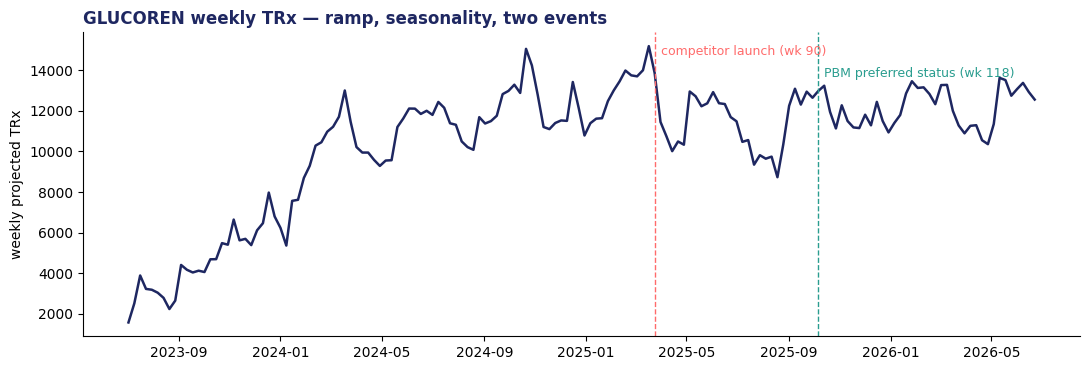

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(df.week, df.trx, color=NAVY, lw=1.8)
ax.axvline(df.week[90], color=CORAL, ls="--", lw=1); ax.text(df.week[91], df.trx.max()*0.97, "competitor launch (wk 90)", color=CORAL, fontsize=9)
ax.axvline(df.week[118], color=TEAL, ls="--", lw=1); ax.text(df.week[119], df.trx.max()*0.90, "PBM preferred status (wk 118)", color=TEAL, fontsize=9)
ax.set_ylabel("weekly projected TRx"); ax.set_title("GLUCOREN weekly TRx — ramp, seasonality, two events", loc="left", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()

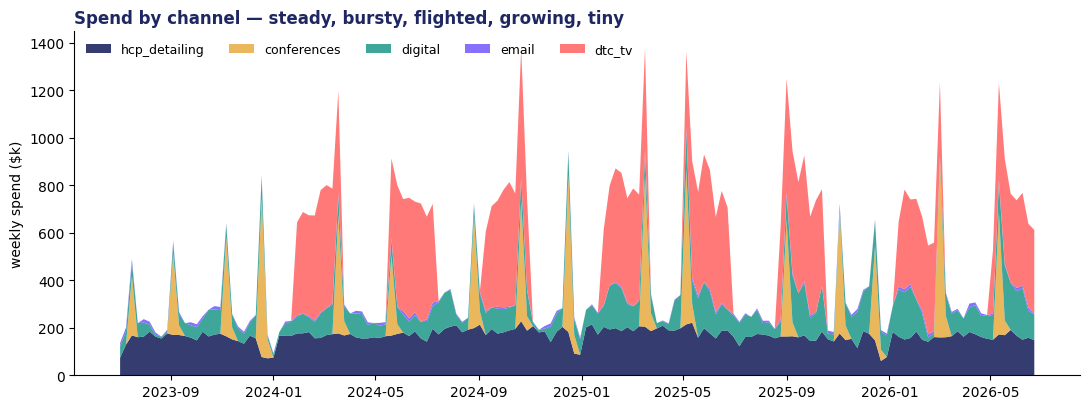

Correlation of weekly spend between channels (co-spend is what inflates VIF later):
               hcp_detailing  conferences  digital  email  dtc_tv
hcp_detailing           1.00         0.04     0.15  -0.19    0.23
conferences             0.04         1.00    -0.07   0.13    0.06
digital                 0.15        -0.07     1.00  -0.01    0.46
email                  -0.19         0.13    -0.01   1.00    0.03
dtc_tv                  0.23         0.06     0.46   0.03    1.00


In [4]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.stackplot(df.week, [df[s] / 1e3 for s in SPEND], labels=CHANNELS, colors=[PALETTE[c] for c in CHANNELS], alpha=0.9)
ax.set_ylabel("weekly spend ($k)"); ax.legend(loc="upper left", ncol=5, frameon=False, fontsize=9)
ax.set_title("Spend by channel — steady, bursty, flighted, growing, tiny", loc="left", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()
print("Correlation of weekly spend between channels (co-spend is what inflates VIF later):")
print(df[SPEND].corr().round(2).rename(index=lambda s: s.replace("_spend", ""), columns=lambda s: s.replace("_spend", "")))

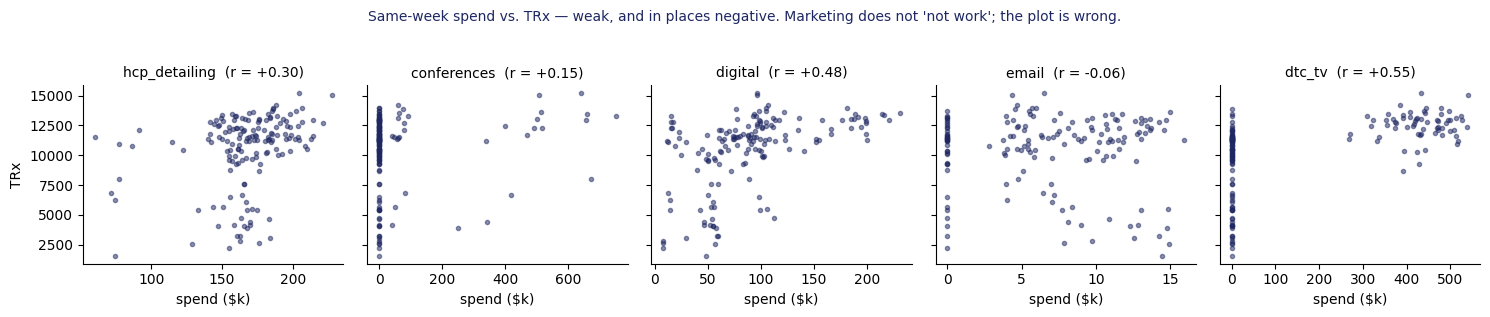

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for ax, c in zip(axes, CHANNELS):
    ax.scatter(df[f"{c}_spend"] / 1e3, df.trx, s=9, alpha=0.5, color=NAVY)
    r = np.corrcoef(df[f"{c}_spend"], df.trx)[0, 1]
    ax.set_title(f"{c}  (r = {r:+.2f})", fontsize=10); ax.set_xlabel("spend ($k)")
axes[0].set_ylabel("TRx")
plt.suptitle("Same-week spend vs. TRx — weak, and in places negative. Marketing does not 'not work'; the plot is wrong.", y=1.04, fontsize=10, color=NAVY)
plt.tight_layout(); plt.show()

**What to notice.** Detailing correlates *negatively* with TRx on a same-week basis (spend was cut in year 3 while TRx kept rising on its base). The naive plot is confounded by the launch ramp and by carryover. Three things stand between raw spend and an honest regression: **carryover** (this week's spend works for weeks), **saturation** (the second million is worth less than the first), and **controls** (ramp, season, competitor, access). The next two sections build them.

## 3. Adstock and Hill saturation

**Geometric adstock.** With spend $x_t$ and decay $\delta \in [0,1)$: $\;a_t = x_t + \delta\, a_{t-1}$. Half-life $= \ln(0.5)/\ln(\delta)$ weeks. TV and detailing carry; email and search do not.

**Hill saturation.** $h(a) = \dfrac{a^s}{a^s + K^s}$. $K$ is the half-saturation point (the adstocked spend at which the channel delivers 50% of its maximum), $s$ the shape ($s>1$ gives an S-curve with a threshold; $s=1$ is concave from zero). The output is in $[0,1)$ and a coefficient $\beta_c$ scales it into TRx.

Together they are the **response curve**. *Adstock decides when; saturation decides how much.*

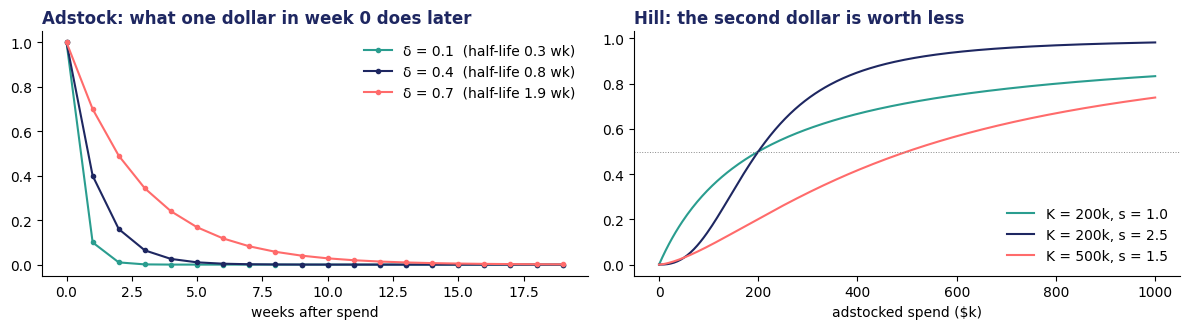

In [6]:
def geometric_adstock(x, decay):
    a = np.zeros(len(x)); a[0] = x[0]
    for i in range(1, len(x)):
        a[i] = x[i] + decay * a[i - 1]
    return a

def hill(a, K, s):
    a = np.asarray(a, float)
    return a ** s / (a ** s + K ** s + 1e-12)

impulse = np.zeros(20); impulse[0] = 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for d, col in zip([0.1, 0.4, 0.7], [TEAL, NAVY, CORAL]):
    axes[0].plot(geometric_adstock(impulse, d), marker="o", ms=3, color=col, label=f"δ = {d}  (half-life {np.log(.5)/np.log(d):.1f} wk)")
axes[0].set_title("Adstock: what one dollar in week 0 does later", loc="left", color=NAVY, fontweight="bold"); axes[0].set_xlabel("weeks after spend"); axes[0].legend(frameon=False)
x = np.linspace(0, 1.0e6, 300)
for (K, s), col in zip([(200e3, 1.0), (200e3, 2.5), (500e3, 1.5)], [TEAL, NAVY, CORAL]):
    axes[1].plot(x / 1e3, hill(x, K, s), color=col, label=f"K = {K/1e3:.0f}k, s = {s}")
axes[1].axhline(0.5, color=GREY, lw=0.7, ls=":"); axes[1].set_title("Hill: the second dollar is worth less", loc="left", color=NAVY, fontweight="bold"); axes[1].set_xlabel("adstocked spend ($k)"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## 4. Baseline controls — the pharma part of the model
Everything that moves TRx and is *not* promotion must be in the model, or the channels will steal its credit. Tonight's four controls:

| control | feature | why it is here |
|---|---|---|
| launch ramp | logistic curve in $t$, fitted on the TRx series | new brands grow on their own (awareness, formulary wins, refills accumulating) |
| seasonality | annual sine/cosine pair | deductible resets, refill timing, flu season for some categories |
| competitor launch | `competitor_active` (0/1 from week 90) | share loss that has nothing to do with our spend |
| formulary access | `pbm_preferred_share` (share of commercial lives with preferred status) | Week 1's lesson: the payer decides whether a script fills |

Leave the last one out and watch what happens to the digital coefficient (section 5c).

fitted ramp: asymptote 12,036 TRx, midpoint week 24.2, scale 8.5 weeks


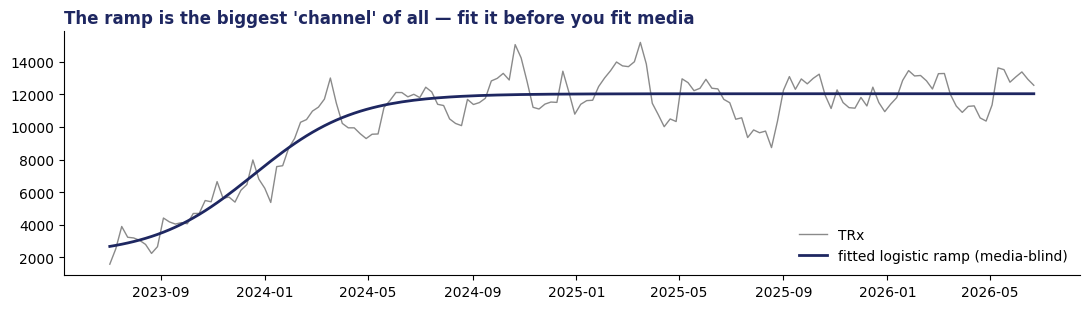

In [7]:
from scipy.optimize import curve_fit
def logistic(tt, L, k, t0, c): return c + L / (1 + np.exp(-(tt - t0) / k))
(L, k, t0, c0), _ = curve_fit(logistic, t, df.trx, p0=[7000, 8, 30, 500], maxfev=20000)
print(f"fitted ramp: asymptote {L+c0:,.0f} TRx, midpoint week {t0:.1f}, scale {k:.1f} weeks")
ctrl = pd.DataFrame({
    "ramp": logistic(t, 1.0, k, t0, 0.0),                       # 0→1 curve; the coefficient scales it
    "season_sin": np.sin(2 * np.pi * t / 52), "season_cos": np.cos(2 * np.pi * t / 52),
    "competitor": df.competitor_active.astype(float),
    "pbm_preferred": df.pbm_preferred_share.astype(float)})
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(df.week, df.trx, color=GREY, lw=1, label="TRx"); ax.plot(df.week, logistic(t, L, k, t0, c0), color=NAVY, lw=2, label="fitted logistic ramp (media-blind)")
ax.legend(frameon=False); ax.set_title("The ramp is the biggest 'channel' of all — fit it before you fit media", loc="left", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()

## 5. Fit the OLS MMM
$$\text{TRx}_t = \beta_0 + \sum_c \beta_c\, h\big(\text{adstock}(x_{c,t};\delta_c);K_c,s_c\big) + \gamma^\top \text{controls}_t + \varepsilon_t$$

$\delta, K, s$ are non-linear, so OLS cannot estimate them. Tonight: a coarse **grid search per channel, one channel at a time, holding the others at their current best, minimizing AIC** (coordinate descent; two passes). $K$ is searched as a multiple of the channel's median non-zero adstocked spend so that the grid means the same thing for a $9k channel and a $480k channel.

The Bayesian alternative (section 12) puts priors on the same three parameters and samples them.

In [8]:
# Decay ranges are channel knowledge, not data: TV and detailing carry for weeks; email and search do not.
# This is the OLS analogue of a Bayesian prior. Section 5c shows what happens when you let the grid roam.
DECAY_RANGE = {"hcp_detailing": [0.4, 0.55, 0.7], "conferences": [0.25, 0.4, 0.55], "digital": [0.1, 0.25, 0.4], "email": [0.1, 0.25], "dtc_tv": [0.4, 0.55, 0.7]}
GRID_DECAY_FREE = [0.1, 0.25, 0.4, 0.55, 0.7]
GRID_KMULT = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 8.0]   # × median non-zero adstocked spend
GRID_SHAPE = [1.0, 1.25, 1.5, 2.0, 2.5]

def transform(spend, p):
    a = geometric_adstock(spend.astype(float), p["decay"])
    K = np.median(a[a > 0]) * p["K_mult"]
    return hill(a, K, p["shape"]), K

def design(params, data=df, controls=ctrl):
    X = controls.copy()
    for ch, p in params.items():
        X[ch], _ = transform(data[f"{ch}_spend"].values, p)
    return sm.add_constant(X)

def fit(params, data=df, controls=ctrl):
    X = design(params, data, controls)
    return sm.OLS(data.trx.values, X).fit(), X

def sweep_channels(best, controls, decay_grid=None):
    for ch in CHANNELS:
        cands = []
        for d, km, s in product(decay_grid or DECAY_RANGE[ch], GRID_KMULT, GRID_SHAPE):
            trial = {c: dict(best[c]) for c in CHANNELS}; trial[ch] = dict(decay=d, K_mult=km, shape=s)
            m, _ = fit(trial, df, controls); cands.append((m.aic, d, km, s))
        aic, d, km, s = min(cands); best[ch] = dict(decay=d, K_mult=km, shape=s)
    return best, aic

best = {ch: dict(decay=0.3, K_mult=1.0, shape=1.0) for ch in CHANNELS}
best, aic = sweep_channels(best, ctrl); print(f"sweep 1 (channels): AIC {aic:,.1f}")
# the ramp's midpoint and scale are hyperparameters too: the media-blind fit above is biased upward by early marketing.
ramp_cands = []
for t0_, k_ in product([18, 22, 26, 30, 34], [6, 9, 12]):
    c_ = ctrl.copy(); c_["ramp"] = logistic(t, 1.0, k_, t0_, 0.0)
    m, _ = fit(best, df, c_); ramp_cands.append((m.aic, t0_, k_))
aic, t0, k = min(ramp_cands); ctrl["ramp"] = logistic(t, 1.0, k, t0, 0.0)
print(f"sweep 2 (ramp): midpoint week {t0}, scale {k} → AIC {aic:,.1f}")
best, aic = sweep_channels(best, ctrl); print(f"sweep 3 (channels): AIC {aic:,.1f}")
print(pd.DataFrame(best).T)

sweep 1 (channels): AIC 2,240.9
sweep 2 (ramp): midpoint week 26, scale 9 → AIC 2,196.3


sweep 3 (channels): AIC 2,171.1
               decay  K_mult  shape
hcp_detailing   0.40     1.5    2.0
conferences     0.55     8.0    2.5
digital         0.25     1.0    1.0
email           0.10     0.5    1.0
dtc_tv          0.70     1.5    2.0


In [9]:
model, X = fit(best)
print(f"R² = {model.rsquared:.3f}   adj. R² = {model.rsquared_adj:.3f}   AIC = {model.aic:,.1f}   n = {int(model.nobs)}")
coef = pd.DataFrame({"coef": model.params, "std_err": model.bse, "t": model.tvalues, "p": model.pvalues}).round(3)
coef

R² = 0.994   adj. R² = 0.994   AIC = 2,171.1   n = 156


,coef,std_err,t,p
const,-993.512,184.253,-5.392,0.0
ramp,7696.722,95.472,80.618,0.0
season_sin,-109.333,29.530,-3.703,0.0
season_cos,-437.319,32.041,-13.649,0.0
competitor,-754.304,63.570,-11.866,0.0
pbm_preferred,2960.534,298.157,9.929,0.0
hcp_detailing,4116.261,378.690,10.870,0.0
conferences,1777.693,83.255,21.353,0.0
digital,2823.466,171.038,16.508,0.0
email,676.297,86.728,7.798,0.0


**Read the media rows.** Each $\beta_c$ is the channel's *maximum weekly TRx contribution* (the Hill output tops out at 1). Every media coefficient should be positive; a negative or insignificant one means the channel is unidentified in this data (too collinear, too little variation, too small) — not that it 'doesn't work'.

### 5a. Diagnostics — what stops you from shipping a wrong model
- **Residuals** should look like noise around zero with no slow waves (a wave means a missed control) and no autocorrelation (Durbin–Watson near 2).
- **VIF** per regressor: < 5 fine, 5–10 suspicious, > 10 the coefficients are not separately identified.
- **Signs and magnitudes** of the media coefficients.
- **Hold-out**: train on the first 104 weeks, predict the last 52.

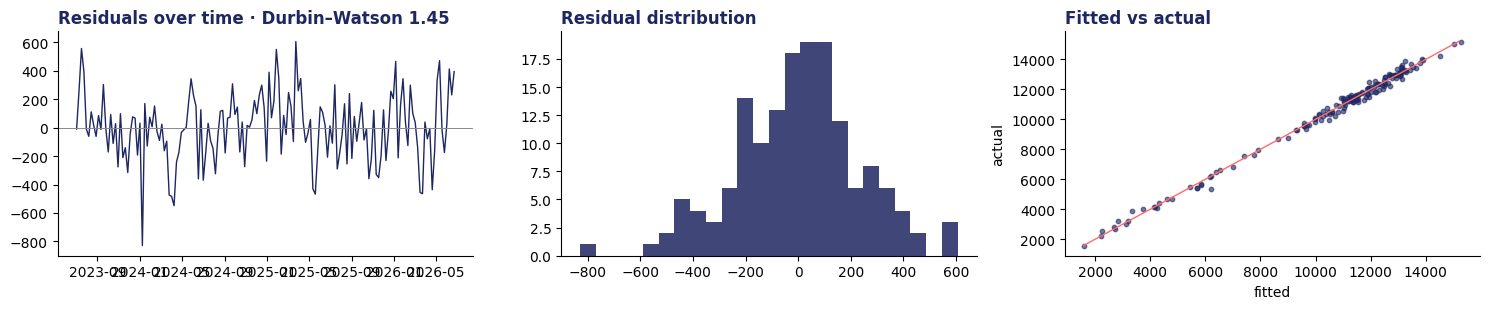

VIF:
ramp             2.07
season_sin       1.12
season_cos       1.32
competitor       2.54
pbm_preferred    2.23
hcp_detailing    1.44
conferences      1.06
digital          1.40
email            1.08
dtc_tv           1.41


In [10]:
resid = model.resid
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
axes[0].plot(df.week, resid, color=NAVY, lw=1); axes[0].axhline(0, color=GREY, lw=.7); axes[0].set_title(f"Residuals over time · Durbin–Watson {durbin_watson(resid):.2f}", loc="left", color=NAVY, fontweight="bold")
axes[1].hist(resid, bins=24, color=NAVY, alpha=.85); axes[1].set_title("Residual distribution", loc="left", color=NAVY, fontweight="bold")
axes[2].scatter(model.fittedvalues, df.trx, s=10, color=NAVY, alpha=.6); axes[2].plot([df.trx.min(), df.trx.max()], [df.trx.min(), df.trx.max()], color=CORAL, lw=1); axes[2].set_xlabel("fitted"); axes[2].set_ylabel("actual"); axes[2].set_title("Fitted vs actual", loc="left", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()
Xv = X.drop(columns="const")
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])], index=Xv.columns).round(2)
print("VIF:"); print(vif.to_string())

hold-out MAPE (weeks 105-156, coefficients trained on 1-104): 4.9%   · before the formulary win 1.6% · after 6.1%


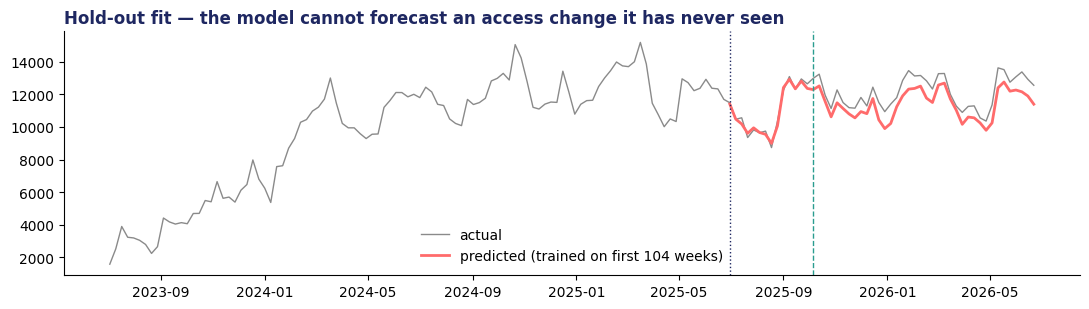

In [11]:
# Hold-out: refit the coefficients on weeks 1-104, predict 105-156.
# pbm_preferred_share is constant (0.38) in the training window, so its effect cannot be estimated there — drop it and see what that costs.
train, test = df.iloc[:104].reset_index(drop=True), df.iloc[104:].reset_index(drop=True)
ctrl_tr = ctrl.drop(columns="pbm_preferred")
m_tr, _ = fit(best, train, ctrl_tr.iloc[:104].reset_index(drop=True))
X_full = design(best, df, ctrl_tr)                       # transforms computed on the FULL series (adstock carries across the split), then sliced
pred_test = m_tr.predict(X_full.iloc[104:])
mape = np.mean(np.abs(pred_test - test.trx.values) / test.trx.values) * 100
mape_pre = np.mean(np.abs(pred_test[:14] - test.trx.values[:14]) / test.trx.values[:14]) * 100
mape_post = np.mean(np.abs(pred_test[14:] - test.trx.values[14:]) / test.trx.values[14:]) * 100
print(f"hold-out MAPE (weeks 105-156, coefficients trained on 1-104): {mape:.1f}%   · before the formulary win {mape_pre:.1f}% · after {mape_post:.1f}%")
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(df.week, df.trx, color=GREY, lw=1, label="actual"); ax.plot(test.week, pred_test, color=CORAL, lw=2, label="predicted (trained on first 104 weeks)")
ax.axvline(df.week[104], color=NAVY, ls=":", lw=1); ax.axvline(df.week[118], color=TEAL, ls="--", lw=1); ax.legend(frameon=False); ax.set_title("Hold-out fit — the model cannot forecast an access change it has never seen", loc="left", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()

**Two caveats you must state in the homework.** (1) This hold-out tests the *coefficients*, not the hyperparameter search — the grid was chosen on all 156 weeks; the stricter version re-runs the grid on the training window only. (2) The formulary step lands inside the test window and the training data never saw one, so the forecast is good until week 118 and biased after it. That is not a modeling failure; it is what an MMM is for — explaining the past — and what it is not for — forecasting an event outside the data (Week 6 does forecasting).

### 5b. Coefficient signs when a control is missing
Drop the formulary-access control and refit. The +9% step at week 118 has to go somewhere.

In [12]:
ctrl_no_access = ctrl.drop(columns="pbm_preferred")
m_na, _ = fit(best, df, ctrl_no_access)
cmp = pd.DataFrame({"with pbm_preferred": model.params, "without": m_na.params}).loc[CHANNELS + ["competitor"]].round(1)
cmp["change_%"] = ((cmp["without"] / cmp["with pbm_preferred"] - 1) * 100).round(0)
print(cmp); print(f"\nAIC with control {model.aic:,.0f}  ·  without {m_na.aic:,.0f}")
print("The +9% step has to go somewhere. Here the competitor coefficient halves (the two events partly cancel) and detailing — cut in year 3 while TRx rose on access — loses credit. In a real brand the access change is usually not even in the dataset; you have to go and get it from the payer-intelligence file (Week 2, category 4).")

               with pbm_preferred  without  change_%
hcp_detailing              4116.3   3371.9     -18.0
conferences                1777.7   1740.6      -2.0
digital                    2823.5   2970.7       5.0
email                       676.3    741.9      10.0
dtc_tv                     3438.5   3415.1      -1.0
competitor                 -754.3   -371.6     -51.0

AIC with control 2,171  ·  without 2,250
The +9% step has to go somewhere. Here the competitor coefficient halves (the two events partly cancel) and detailing — cut in year 3 while TRx rose on access — loses credit. In a real brand the access change is usually not even in the dataset; you have to go and get it from the payer-intelligence file (Week 2, category 4).


### 5c. Identifiability — what happens when the grid roams
Re-run the search with every channel allowed any decay in {0.1 … 0.7}, and compare the fit and the ROI each version implies.

In [13]:
free = {ch: dict(best[ch]) for ch in CHANNELS}
free, aic_free = sweep_channels(free, ctrl, decay_grid=GRID_DECAY_FREE)
m_free, X_free = fit(free)
vif_free = pd.Series([variance_inflation_factor(X_free.drop(columns="const").values, i) for i in range(X_free.shape[1] - 1)], index=X_free.drop(columns="const").columns)
def avg_roi(params, m):
    return pd.Series({c: m.params[c] * transform(df[f"{c}_spend"].values, params[c])[0].sum() * REV_PER_TRX / df[f"{c}_spend"].sum() for c in CHANNELS})
cmp = pd.DataFrame({"decay (bounded)": {c: best[c]["decay"] for c in CHANNELS}, "decay (free)": {c: free[c]["decay"] for c in CHANNELS},
                    "VIF (bounded)": vif[CHANNELS].round(1), "VIF (free)": vif_free[CHANNELS].round(1),
                    "avg ROI (bounded)": avg_roi(best, model).round(2), "avg ROI (free)": avg_roi(free, m_free).round(2)})
print(cmp); print(f"\nAIC bounded {model.aic:,.1f} · free {aic_free:,.1f}  (a difference under 2 is noise)")
print("Two models that fit the data equally well can disagree about a channel's carryover and therefore its ROI. That is the identifiability problem in one table —")
print("and the reason to bound the grid with channel knowledge, report the range, and calibrate with an experiment (section 10).")

               decay (bounded)  decay (free)  VIF (bounded)  VIF (free)  avg ROI (bounded)  avg ROI (free)
hcp_detailing             0.40          0.25            1.4         1.4               1.88            1.76
conferences               0.55          0.55            1.1         1.1               1.09            1.10
digital                   0.25          0.25            1.4         1.4               3.70            3.69
email                     0.10          0.10            1.1         1.1              14.68           15.13
dtc_tv                    0.70          0.70            1.4         1.4               1.21            1.21

AIC bounded 2,171.1 · free 2,169.5  (a difference under 2 is noise)
Two models that fit the data equally well can disagree about a channel's carryover and therefore its ROI. That is the identifiability problem in one table —
and the reason to bound the grid with channel knowledge, report the range, and calibrate with an experiment (section 10).


## 6. Decomposition — base vs. incremental
*Of the TRx we generated, how much would the brand have done on its own, and how much did each channel add?* Show this chart **before** any ROI number: leadership has to see the system before they hear a ratio.

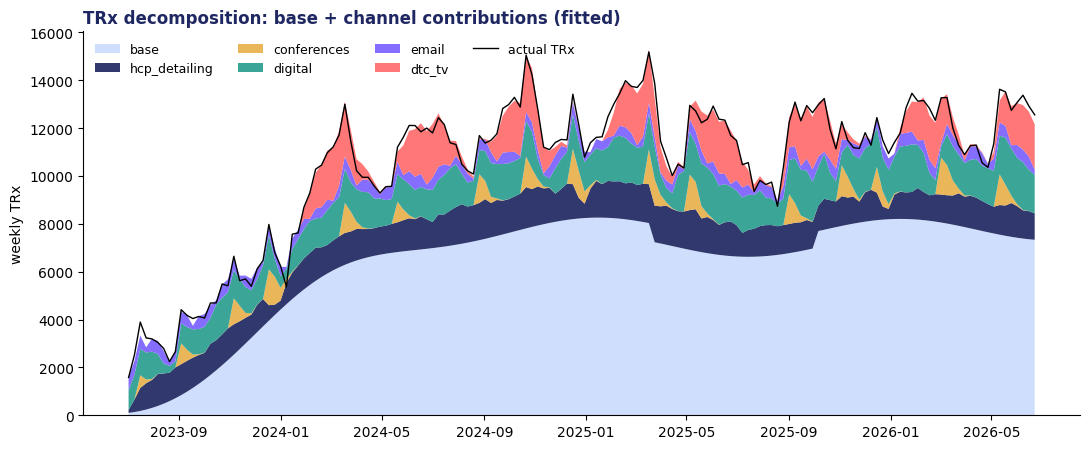

Share of fitted TRx (%):
base             60.8
hcp_detailing    12.1
conferences       2.4
digital          12.8
email             3.8
dtc_tv            8.2

Incremental (all channels): 39.2% of TRx  ·  Unexplained: 0 TRx (0.00%)


In [14]:
contrib = pd.DataFrame(index=df.index)
for ch in CHANNELS:
    h, _ = transform(df[f"{ch}_spend"].values, best[ch]); contrib[ch] = model.params[ch] * h
base = model.params["const"] + (X[ctrl.columns] * model.params[ctrl.columns]).sum(axis=1)
contrib.insert(0, "base", base.values)
order = ["base"] + CHANNELS
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.stackplot(df.week, [contrib[c] for c in order], labels=order, colors=[PALETTE[c] for c in order], alpha=.92)
ax.plot(df.week, df.trx, color="black", lw=1.0, label="actual TRx")
ax.legend(loc="upper left", ncol=4, frameon=False, fontsize=9); ax.set_ylabel("weekly TRx")
ax.set_title("TRx decomposition: base + channel contributions (fitted)", loc="left", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()
share = (contrib[order].sum() / contrib[order].sum().sum() * 100).round(1)
print("Share of fitted TRx (%):"); print(share.to_string())
print(f"\nIncremental (all channels): {100-share['base']:.1f}% of TRx  ·  Unexplained: {(df.trx.sum() - contrib[order].sum().sum()):,.0f} TRx ({(df.trx.sum() - contrib[order].sum().sum())/df.trx.sum()*100:.2f}%)")

## 7. ROI — average vs. marginal
- **Average ROI** = revenue from the channel's total contribution ÷ its total spend. A *reporting* number: 'what did we get for what we spent'.
- **Marginal ROI** = revenue from the *next* dollar. A *decision* number: 'where should the next dollar go'. We approximate it by raising every week's spend in one channel by 5% and re-evaluating the fitted model.

Saturation guarantees that these two rankings differ. Confusing them in front of a CFO is the most common MMM error.

In [15]:
def predict_total(spend_dict):
    total = base.values.copy()
    for ch in CHANNELS:
        a = geometric_adstock(spend_dict[ch].astype(float), best[ch]["decay"])
        _, K = transform(df[f"{ch}_spend"].values, best[ch])        # K is fixed at the fitted value — it is a model parameter, not a function of the scenario
        total = total + model.params[ch] * hill(a, K, best[ch]["shape"])
    return total.sum()

base_spend = {ch: df[f"{ch}_spend"].values.astype(float) for ch in CHANNELS}
base_total = predict_total(base_spend)
rows = []
for ch in CHANNELS:
    sp = base_spend[ch].sum(); tr = contrib[ch].sum()
    bumped = {c: v.copy() for c, v in base_spend.items()}; bumped[ch] = bumped[ch] * 1.05
    d_trx = predict_total(bumped) - base_total; d_sp = sp * 0.05
    rows.append(dict(channel=ch, spend_M=sp / 1e6, incremental_trx=tr, revenue_M=tr * REV_PER_TRX / 1e6, avg_ROI=tr * REV_PER_TRX / sp,
                     marginal_ROI=d_trx * REV_PER_TRX / d_sp, cost_per_incremental_trx=sp / tr))
roi = pd.DataFrame(rows).set_index("channel")
roi["rank_avg"] = roi.avg_ROI.rank(ascending=False).astype(int); roi["rank_marginal"] = roi.marginal_ROI.rank(ascending=False).astype(int)
print(roi.round(2))

               spend_M  incremental_trx  revenue_M  avg_ROI  marginal_ROI  cost_per_incremental_trx  rank_avg  rank_marginal
channel                                                                                                                     
hcp_detailing    26.10        196383.39      49.10     1.88          2.55                    132.91         3              2
conferences       9.07         39614.64       9.90     1.09          1.19                    228.87         5              4
digital          14.08        208425.18      52.11     3.70          1.76                     67.53         2              3
email             1.04         61256.44      15.31    14.68          4.61                     17.03         1              1
dtc_tv           27.56        133298.56      33.32     1.21          1.18                    206.73         4              5


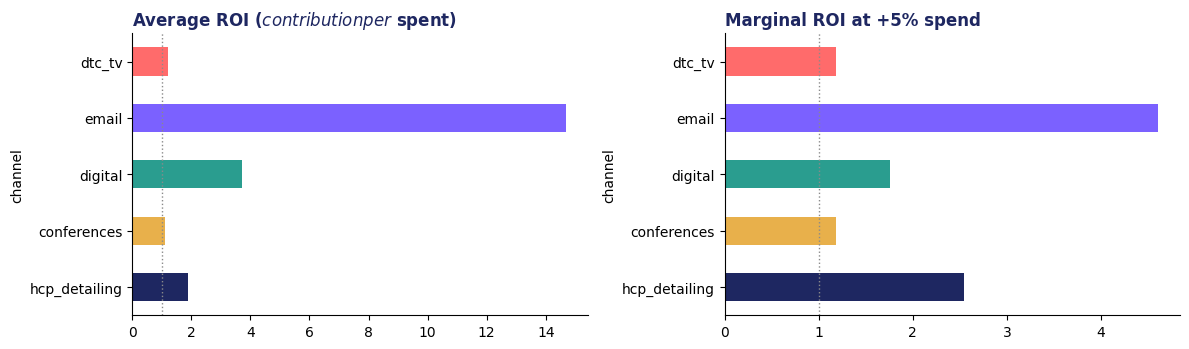

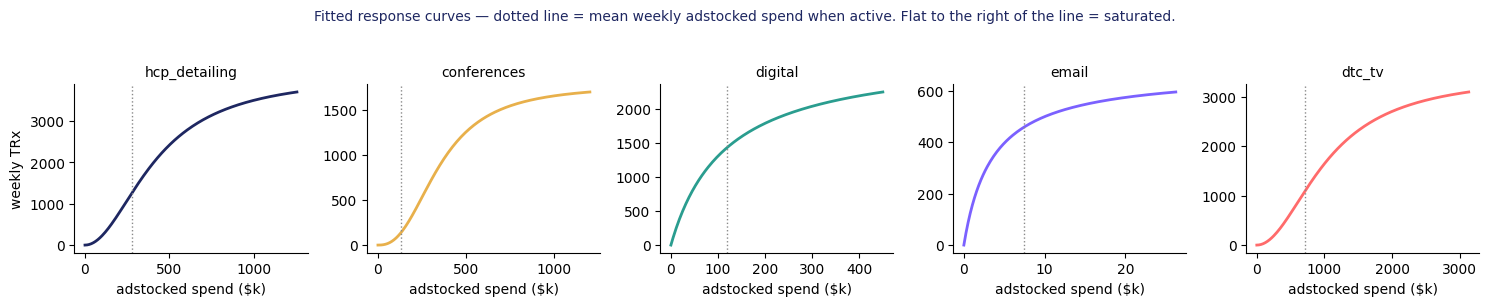

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
roi.avg_ROI.plot.barh(ax=axes[0], color=[PALETTE[c] for c in roi.index]); axes[0].axvline(1, color=GREY, ls=":", lw=1); axes[0].set_title("Average ROI ($ contribution per $ spent)", loc="left", color=NAVY, fontweight="bold")
roi.marginal_ROI.plot.barh(ax=axes[1], color=[PALETTE[c] for c in roi.index]); axes[1].axvline(1, color=GREY, ls=":", lw=1); axes[1].set_title("Marginal ROI at +5% spend", loc="left", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()
# Response curves at the fitted parameters: where each channel sits on its own curve (mean weekly adstocked spend)
fig, axes = plt.subplots(1, 5, figsize=(15, 2.9))
for ax, ch in zip(axes, CHANNELS):
    a = geometric_adstock(df[f"{ch}_spend"].values.astype(float), best[ch]["decay"]); _, K = transform(df[f"{ch}_spend"].values, best[ch])
    grid = np.linspace(0, max(a.max() * 1.6, K * 3), 200)
    ax.plot(grid / 1e3, model.params[ch] * hill(grid, K, best[ch]["shape"]), color=PALETTE[ch], lw=2)
    ax.axvline(np.mean(a[a > 0]) / 1e3, color=GREY, ls=":", lw=1); ax.set_title(ch, fontsize=10); ax.set_xlabel("adstocked spend ($k)")
axes[0].set_ylabel("weekly TRx")
plt.suptitle("Fitted response curves — dotted line = mean weekly adstocked spend when active. Flat to the right of the line = saturated.", y=1.04, fontsize=10, color=NAVY)
plt.tight_layout(); plt.show()

**Read the table.** Email has the highest average ROI *and* the highest marginal ROI — and it is $1.3M of a $78M budget. Its marginal number is the slope at +5% (about $65k). The question the Brand Lead will ask — 'so put $5M into email?' — is answered in section 11, and the answer is no. Digital is the channel with headroom; DTC TV is the channel with the lowest marginal return and the biggest budget.

## 8. Grade against the truth (instructor file)
Synthetic data has a known answer. If `_INSTRUCTOR_mmm_truth.json` is in the folder, compare the fitted contributions and ROI with the generating model. The point is not to hit the truth — it is to see *how* the method misses.

In [17]:
truth_path = INSTR / "_INSTRUCTOR_mmm_truth.json"
if truth_path.exists():
    truth = json.load(open(truth_path)); tcon = pd.read_csv(INSTR / "_INSTRUCTOR_true_contributions.csv")
    g = pd.DataFrame({"fitted_trx": contrib[CHANNELS].sum(), "true_trx": tcon[CHANNELS].sum(),
                      "fitted_avg_ROI": roi.avg_ROI, "true_avg_ROI": pd.Series({c: v["roi"] for c, v in truth["true_average_roi"].items()}),
                      "fitted_marginal": roi.marginal_ROI, "true_marginal": pd.Series(truth["true_marginal_roi_plus5pct"])})
    g["trx_error_%"] = ((g.fitted_trx / g.true_trx - 1) * 100).round(0)
    print(g.round(2))
    print(f"\nbase share: fitted {share['base']:.1f}%  ·  true {truth['base_share_of_trx']*100:.1f}%")
    hp = pd.DataFrame({ch: dict(true_decay=truth["params"][ch]["decay"], fit_decay=best[ch]["decay"], true_shape=truth["params"][ch]["shape"], fit_shape=best[ch]["shape"]) for ch in CHANNELS}).T
    print("\nhyperparameters:"); print(hp)
else:
    print("Instructor truth file not present — grading skipped (students run without it).")

               fitted_trx  true_trx  fitted_avg_ROI  true_avg_ROI  fitted_marginal  true_marginal  trx_error_%
hcp_detailing   196383.39  217889.6            1.88          2.09             2.55           1.61        -10.0
conferences      39614.64   36272.9            1.09          1.00             1.19           0.80          9.0
digital         208425.18  201731.5            3.70          3.58             1.76           1.85          3.0
email            61256.44   46158.2           14.68         11.06             4.61           3.72         33.0
dtc_tv          133298.56  141462.4            1.21          1.28             1.18           1.04         -6.0

base share: fitted 60.8%  ·  true 60.7%

hyperparameters:
               true_decay  fit_decay  true_shape  fit_shape
hcp_detailing        0.55       0.40         1.3        2.0
conferences          0.35       0.55         1.8        2.5
digital              0.25       0.25         1.0        1.0
email                0.10       0.1

**What to take from the grading.** The ranking is right; the levels are off by tens of percent for the smaller channels; the decay is recovered within one grid step. That is a good MMM. Anyone who presents an MMM ROI to two decimal places has not done this exercise.

## 9. Uncertainty — ranges, not points
Two sources of uncertainty, two cheap tools:
1. **Sampling error in the coefficients** — a *moving-block bootstrap* of the residuals (blocks of 8 weeks keep the autocorrelation) refits the model 300 times.
2. **Hyperparameter uncertainty** — the grid picked one $(\delta, K, s)$ per channel, but neighbouring cells fit almost as well. Re-run ROI at the runner-up cells.

In [18]:
B, BLOCK = 300, 8
fitted = model.fittedvalues.values; res = resid.values
boot = {ch: [] for ch in CHANNELS}
rng = np.random.default_rng(7)
for b in range(B):
    starts = rng.integers(0, T - BLOCK, size=T // BLOCK + 1)
    e = np.concatenate([res[s:s + BLOCK] for s in starts])[:T]
    y_b = fitted + e
    m_b = sm.OLS(y_b, X).fit()
    for ch in CHANNELS:
        h, _ = transform(df[f"{ch}_spend"].values, best[ch]); boot[ch].append(m_b.params[ch] * h.sum() * REV_PER_TRX / base_spend[ch].sum())
ci = pd.DataFrame({ch: np.percentile(boot[ch], [10, 50, 90]) for ch in CHANNELS}, index=["p10", "p50", "p90"]).T.round(2)
ci["point"] = roi.avg_ROI.round(2); ci["width"] = (ci.p90 - ci.p10).round(2)
print("Average ROI, 80% bootstrap interval:"); print(ci)

Average ROI, 80% bootstrap interval:
                 p10    p50    p90  point  width
hcp_detailing   1.69   1.90   2.12   1.88   0.43
conferences     1.02   1.09   1.15   1.09   0.13
digital         3.40   3.68   3.99   3.70   0.59
email          12.64  14.83  16.81  14.68   4.17
dtc_tv          1.15   1.21   1.26   1.21   0.11


In [19]:
# Hyperparameter sensitivity: for each channel, the three best grid cells by AIC and the ROI each implies
sens = []
for ch in CHANNELS:
    cands = []
    for d, km, s in product(DECAY_RANGE[ch], GRID_KMULT, GRID_SHAPE):
        trial = {c: dict(best[c]) for c in CHANNELS}; trial[ch] = dict(decay=d, K_mult=km, shape=s)
        m, _ = fit(trial); h, _ = transform(df[f"{ch}_spend"].values, trial[ch])
        cands.append((m.aic, d, km, s, m.params[ch] * h.sum() * REV_PER_TRX / base_spend[ch].sum()))
    cands.sort()
    for rank, (aic, d, km, s, r) in enumerate(cands[:3], 1):
        sens.append(dict(channel=ch, rank=rank, dAIC=round(aic - cands[0][0], 1), decay=d, K_mult=km, shape=s, avg_ROI=round(r, 2)))
sens = pd.DataFrame(sens)
print(sens.to_string(index=False))
print("\nCells within ~2 AIC of the best are statistically indistinguishable. Report the ROI range across them, not the winner.")

      channel  rank  dAIC  decay  K_mult  shape  avg_ROI
hcp_detailing     1   0.0   0.40    4.00   1.50     1.99
hcp_detailing     2   0.0   0.40    2.00   2.00     1.72
hcp_detailing     3   0.1   0.40    1.50   2.00     1.88
  conferences     1   0.0   0.55    8.00   2.50     1.09
  conferences     2   7.7   0.55    8.00   2.00     1.19
  conferences     3  25.7   0.55    8.00   1.50     1.35
      digital     1   0.0   0.25    1.00   1.00     3.70
      digital     2   0.8   0.25    0.75   1.00     4.08
      digital     3   1.6   0.25    1.50   1.00     3.27
        email     1   0.0   0.10    0.50   1.00    14.68
        email     2   0.6   0.10    0.75   1.00    13.25
        email     3   0.6   0.10    0.50   1.25    12.93
       dtc_tv     1   0.0   0.70    1.50   2.00     1.21
       dtc_tv     2   7.2   0.70    2.00   1.50     1.32
       dtc_tv     3   9.4   0.70    1.50   2.50     1.09

Cells within ~2 AIC of the best are statistically indistinguishable. Report the ROI ran

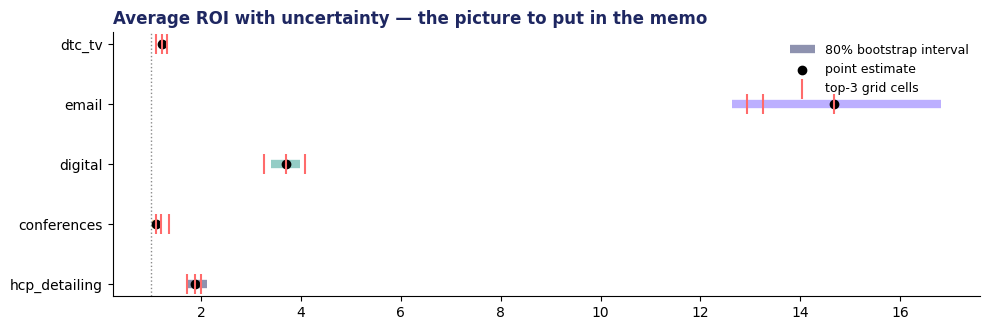

In [20]:
fig, ax = plt.subplots(figsize=(10, 3.4))
y = np.arange(len(CHANNELS))
ax.hlines(y, ci.p10, ci.p90, color=[PALETTE[c] for c in CHANNELS], lw=6, alpha=.5, label="80% bootstrap interval")
ax.scatter(ci.point, y, color="black", zorder=3, label="point estimate")
for i, ch in enumerate(CHANNELS):
    rr = sens[sens.channel == ch].avg_ROI; ax.scatter(rr, [i] * len(rr), marker="|", s=200, color=CORAL, zorder=4, label="top-3 grid cells" if i == 0 else None)
ax.set_yticks(y); ax.set_yticklabels(CHANNELS); ax.axvline(1, color=GREY, ls=":", lw=1); ax.legend(frameon=False, fontsize=9)
ax.set_title("Average ROI with uncertainty — the picture to put in the memo", loc="left", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()

## 10. Calibrate with an experiment — the DTC-TV geo holdout
The brand ran flight 7 (weeks 132–140) with TV **dark in 10 of 40 DMAs**. Difference-in-differences on the DMA panel gives a causal estimate of TV's lift for that flight — one number the MMM can be checked against (and, in a Bayesian MMM, a prior for $\beta_{TV}$).

period     pre   test  weeks  dmas
group                             
exposed  74139  82959      8    30
holdout  17719  17453      8    10

exposed growth 1.119 · holdout growth 0.985 → incremental TRx in exposed DMAs 9,933 (13.6% lift)
TV spend in exposed DMAs during the test: $2.36M → experiment ROI 1.05
MMM-implied ROI for the same flight and DMAs: 0.97   (all-period MMM average ROI for TV: 1.21)
truth: 14.0% lift · ROI 1.08


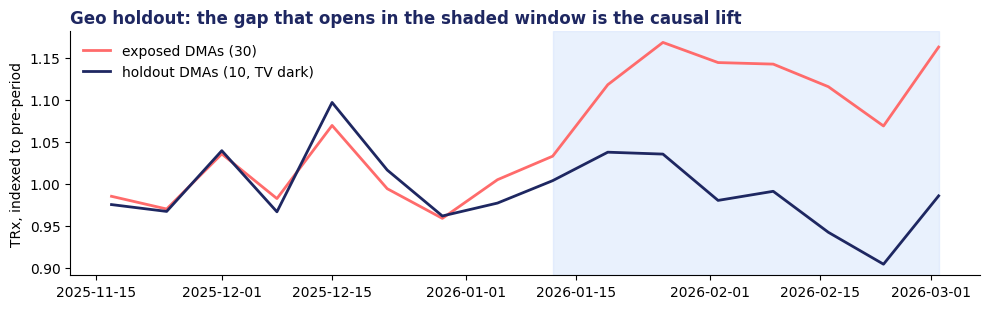

In [21]:
geo = pd.read_csv(DATA / "glucoren_geo_lift_dtc_tv.csv", parse_dates=["week"])
cell = geo.groupby(["group", "period"]).trx.sum().unstack("period")
cell["weeks"] = geo.groupby(["group", "period"]).week.nunique().unstack("period")["test"]
n_dma = geo.groupby("group").dma.nunique()
print(cell.assign(dmas=n_dma))
# DiD: growth pre→test in exposed DMAs minus growth in holdout DMAs, applied to exposed pre-level
g_exp = cell.loc["exposed", "test"] / cell.loc["exposed", "pre"]; g_hold = cell.loc["holdout", "test"] / cell.loc["holdout", "pre"]
counterfactual_exposed = cell.loc["exposed", "pre"] * g_hold
lift_trx = cell.loc["exposed", "test"] - counterfactual_exposed
lift_pct = lift_trx / counterfactual_exposed * 100
tv_spend_exposed = geo[(geo.period == "test") & (geo.group == "exposed")].dtc_tv_spend_alloc.sum()
geo_roi = lift_trx * REV_PER_TRX / tv_spend_exposed
print(f"\nexposed growth {g_exp:.3f} · holdout growth {g_hold:.3f} → incremental TRx in exposed DMAs {lift_trx:,.0f} ({lift_pct:.1f}% lift)")
print(f"TV spend in exposed DMAs during the test: ${tv_spend_exposed/1e6:.2f}M → experiment ROI {geo_roi:.2f}")
# the MMM's view of the same flight: fitted TV contribution in the test weeks, scaled to exposed DMAs' share of TRx
test_idx = df.index[df.week.isin(geo[geo.period == "test"].week.unique())]
exposed_share = geo[(geo.period == "pre") & (geo.group == "exposed")].trx.sum() / geo[geo.period == "pre"].trx.sum()
mmm_flight_roi = contrib.loc[test_idx, "dtc_tv"].sum() * exposed_share * REV_PER_TRX / tv_spend_exposed
print(f"MMM-implied ROI for the same flight and DMAs: {mmm_flight_roi:.2f}   (all-period MMM average ROI for TV: {roi.loc['dtc_tv','avg_ROI']:.2f})")
gt = INSTR / "_INSTRUCTOR_geo_lift_truth.json"
if gt.exists():
    g_true = json.load(open(gt)); print(f"truth: {g_true['true_lift_pct_in_exposed_dmas']}% lift · ROI {g_true['implied_true_roi_test_period']}")
# DMA-level picture
piv = geo.groupby(["group", "week"]).trx.sum().unstack("group"); piv = piv / piv.iloc[:8].mean()
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(piv.index, piv.exposed, color=CORAL, lw=2, label="exposed DMAs (30)"); ax.plot(piv.index, piv.holdout, color=NAVY, lw=2, label="holdout DMAs (10, TV dark)")
ax.axvspan(geo[geo.period == "test"].week.min(), geo.week.max(), color=ICE, alpha=.4); ax.legend(frameon=False); ax.set_ylabel("TRx, indexed to pre-period")
ax.set_title("Geo holdout: the gap that opens in the shaded window is the causal lift", loc="left", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()

**Why the two numbers differ, and why that is fine.** The experiment measures *this* flight, in *these* DMAs, at *this* point in the launch; the MMM averages over three years including the expensive early flights. Where they disagree by more than the bootstrap interval, the experiment wins — it has the cleaner identification. In a Bayesian MMM you would encode the experiment as an informative prior on $\beta_{TV}$ (section 12).

## 11. Reallocation — equalize marginal ROI, under constraints
The textbook rule: at the optimum every channel has the same marginal ROI, so move money from the lowest to the highest in small steps and re-evaluate (the curves move under you). Real constraints tonight:
- **Floors**: detailing ≥ 85% of current (a field force is not a dial); conferences ≥ 60% (contracted sponsorships).
- **Caps**: email ≤ 2.5× current (list size, CAN-SPAM, HCP fatigue); digital ≤ 1.8× (inventory, MLR-approved content).
- **Confidence**: only move money where the marginal-ROI gap exceeds the bootstrap noise.

Total budget held fixed. Two scenarios: *conservative* (move at most $5M) and *aggressive* (move up to $15M).

In [22]:
def scenario(max_move_M, step_M=0.25, floors=None, caps=None):
    floors = floors or {"hcp_detailing": 0.85, "conferences": 0.60, "digital": 0.5, "email": 0.5, "dtc_tv": 0.5}
    caps = caps or {"hcp_detailing": 1.3, "conferences": 1.3, "digital": 1.8, "email": 2.5, "dtc_tv": 1.3}
    cur = {c: v.copy() for c, v in base_spend.items()}; moved = 0.0; log = []
    def marg(sp, ch, sign):
        s = {c: v.copy() for c, v in sp.items()}; s[ch] = s[ch] * (1 + sign * step_M * 1e6 / s[ch].sum())
        return (predict_total(s) - predict_total(sp)) * REV_PER_TRX / (step_M * 1e6) * sign
    while moved < max_move_M:
        m_up = {c: marg(cur, c, +1) for c in CHANNELS if cur[c].sum() + step_M * 1e6 <= caps[c] * base_spend[c].sum()}
        m_dn = {c: marg(cur, c, -1) for c in CHANNELS if cur[c].sum() - step_M * 1e6 >= floors[c] * base_spend[c].sum()}
        if not m_up or not m_dn: break
        to, frm = max(m_up, key=m_up.get), min(m_dn, key=m_dn.get)
        if to == frm or m_up[to] - m_dn[frm] < 0.15: break          # stop when the gap is inside the noise
        cur[to] = cur[to] * (1 + step_M * 1e6 / cur[to].sum()); cur[frm] = cur[frm] * (1 - step_M * 1e6 / cur[frm].sum()); moved += step_M
        log.append((frm, to))
    out = pd.DataFrame({"current_$M": {c: base_spend[c].sum() / 1e6 for c in CHANNELS}, "proposed_$M": {c: cur[c].sum() / 1e6 for c in CHANNELS}})
    out["change_$M"] = out["proposed_$M"] - out["current_$M"]
    gain = predict_total(cur) - base_total
    return out.round(2), gain, moved

for name, mm in [("Conservative (≤ $5M moved)", 5), ("Aggressive (≤ $15M moved)", 15)]:
    tbl, gain, moved = scenario(mm)
    print(f"\n{name}: moved ${moved:.2f}M over the 3-year period → +{gain:,.0f} TRx (≈ ${gain*REV_PER_TRX/1e6:.1f}M contribution) on the same total budget, +{gain/df.trx.sum()*100:.1f}% of TRx")
    print(tbl)


Conservative (≤ $5M moved): moved $5.00M over the 3-year period → +27,153 TRx (≈ $6.8M contribution) on the same total budget, +1.7% of TRx
               current_$M  proposed_$M  change_$M
hcp_detailing       26.10        30.35       4.25
conferences          9.07         7.57      -1.50
digital             14.08        14.08       0.00
email                1.04         1.79       0.75
dtc_tv              27.56        24.06      -3.50



Aggressive (≤ $15M moved): moved $11.00M over the 3-year period → +43,982 TRx (≈ $11.0M contribution) on the same total budget, +2.7% of TRx
               current_$M  proposed_$M  change_$M
hcp_detailing       26.10        33.85       7.75
conferences          9.07         5.82      -3.25
digital             14.08        15.83       1.75
email                1.04         2.54       1.50
dtc_tv              27.56        19.81      -7.75


In [23]:
# The Brand Lead's question: 'so put $5M into email?'
s = {c: v.copy() for c, v in base_spend.items()}; s["email"] = s["email"] * (1 + 5e6 / s["email"].sum())
print(f"Email at +$5M (≈ {5e6/base_spend['email'].sum():.0%} increase): incremental TRx {predict_total(s) - base_total:,.0f} → ROI on the added $5M = {(predict_total(s)-base_total)*REV_PER_TRX/5e6:.2f}")
print("Marginal ROI at +5% is a slope at a point. It says nothing about +400%. Saturation is why the highest-ROI channel is rarely the one to grow most.")

Email at +$5M (≈ 479% increase): incremental TRx 27,503 → ROI on the added $5M = 1.38
Marginal ROI at +5% is a slope at a point. It says nothing about +400%. Saturation is why the highest-ROI channel is rarely the one to grow most.


## 12. Bayesian MMM (appendix — not run in class)
The same model with priors on $\delta$, $K$, $s$ and $\beta$, sampled with MCMC. What you gain: credible intervals on everything including ROI, the ability to encode the geo-lift result as a prior, and questions like *P(ROI_digital > ROI_TV + 1)*. What it costs: minutes of sampling, harder debugging, and priors you must be able to defend. Install `pymc-marketing` and run this after class; the homework bonus asks for it.

In [24]:
BAYES = False   # set True after `pip install pymc-marketing` (sampling takes a few minutes)
if BAYES:
    from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
    Xb = df[["week"] + SPEND].copy()
    for c in ctrl.columns: Xb[c] = ctrl[c].values
    mmm = MMM(date_column="week", channel_columns=SPEND, control_columns=list(ctrl.columns),
              adstock=GeometricAdstock(l_max=10), saturation=LogisticSaturation())
    mmm.fit(X=Xb, y=df.trx, chains=2, draws=1000, tune=1000, target_accept=0.9, random_seed=7)
    mmm.plot_posterior_predictive(original_scale=True); mmm.plot_channel_contributions_grid()
    # ROI posteriors: mmm.compute_channel_contribution_original_scale() / spend, per draw
else:
    print("Bayesian section skipped (BAYES = False).")

Bayesian section skipped (BAYES = False).


## 13. What to take away
1. **Adstock and saturation are not optional.** Without them you are estimating a different model than you think you are.
2. **In pharma the controls are the model.** Ramp, season, competitor, access. Leave one out and a channel steals its credit (section 5b).
3. **Average ROI reports; marginal ROI decides.** Saturation guarantees the rankings differ.
4. **Ranges, not points.** Bootstrap the coefficients, re-run the neighbouring grid cells, and put the interval chart in the memo.
5. **Calibrate.** One clean holdout per major channel per year beats a more elaborate model. Where the experiment and the model disagree, the experiment wins.
6. **The optimizer needs constraints and a stopping rule**, or it will pour the budget into the smallest channel.

### Try before Week 4 (not graded)
- Re-run the grid with `GRID_DECAY = [0.05, 0.2, 0.35, 0.5, 0.65, 0.8]`. Does the TV ROI range widen or narrow?
- Replace `competitor` (a step) with a 6-week linear ramp. What happens to the detailing coefficient?
- Use `hcp_calls` instead of `hcp_detailing_spend` as the detailing input. Which is the better 'dose'?
- Homework 1 does all of this on the same data and adds a memo. Released tonight; due Monday, October 12.
